In [1]:
import pandas as pd
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

In [2]:
color_map = {
    "progenitor": "#6abd12",
    "MBO": "#bce590",

    "VZ_neuroblast_1": "#facc15",
    "VZ_neuroblast_2": "#fde047",
    "VZ_neuroblast_3": "#fef08a",

    "NTZ_neuroblast_1": "#7d5207",
    "NTZ_neuroblast_2": "#b39054",
    "NTZ_neuroblast_3": "#ecd09f",

    "GCP": "#7f1d1d",
    "GC_diff_1": "#f76161",
    "GC_diff_2": "#ff9f9f",
    "GC_defined": "#ffd5d5",

    "GCP/UBCP": "#f27500",
    "GC/UBC_diff": "#fb9f4a",
    "UBC_diff": "#f7b272",
    "UBC_defined": "#fdc999",

    "Purkinje_diff": "#0a229b",
    "Purkinje_defined": "#90a2f2",
    "Purkinje_maturing": "#cbd4f9",

    "interneuron_diff": "#069372",
    "interneuron_defined": "#7cd9c3",
    "GABA_DN_defined": "#c2ece2",

    "glut_DN_defined": "#ae3970",
    "isth_N_diff": "#fdb8e9",
    "isth_N_defined": "#ffe1f7",

    "glioblast": "#550584",
    "oligo_progenitor": "#8c2ebf",
    "oligodendrocyte": "#c38ce3",
    "astrocyte": "#d7c8f0",
    
    "meningeal": "#1a1a1a",
    "parabrachial": "#4d4d4d"
}

In [3]:
def make_density_map(
    df_sub,
    x_col="MDS_1",
    y_col="MDS_2",
    grid_size=50,
    coord_range=(-1, 1),
    bw_method=None,
    min_cells=3
):

    use = df_sub[
        df_sub[x_col].between(coord_range[0], coord_range[1])
        & df_sub[y_col].between(coord_range[0], coord_range[1])
    ].dropna(subset=[x_col, y_col])

    if len(use) < min_cells:
        return np.full(
            (grid_size, grid_size),
            np.nan
        )

    x_grid = np.linspace(
        coord_range[0],
        coord_range[1],
        grid_size
    )

    y_grid = np.linspace(
        coord_range[0],
        coord_range[1],
        grid_size
    )

    xx, yy = np.meshgrid(x_grid, y_grid)

    coordinates = np.vstack([
        use[x_col].to_numpy(),
        use[y_col].to_numpy()
    ])

    try:
        kde = gaussian_kde(
            coordinates,
            bw_method=bw_method
        )

        grid_positions = np.vstack([
            xx.ravel(),
            yy.ravel()
        ])

        density = kde(
            grid_positions
        ).reshape(grid_size, grid_size)

    except (np.linalg.LinAlgError, ValueError):
        return np.full(
            (grid_size, grid_size),
            np.nan
        )

    density_sum = density.sum()

    if density_sum > 0:
        density = density / density_sum

    return density

In [4]:
def make_annotation_density_maps(
    df_stage,
    annotation_col="annotation",
    x_col="MDS_1",
    y_col="MDS_2",
    annotations=None,
    grid_size=50,
    coord_range=(-1, 1),
    bw_method=None,
    min_cells=3
):
    if annotations is None:
        annotations = sorted(
            df_stage[annotation_col].dropna().unique()
        )

    density_maps = {}
    cell_counts = {}

    for anno in annotations:
        df_sub = df_stage[
            df_stage[annotation_col] == anno
        ]

        cell_counts[anno] = len(df_sub)

        if len(df_sub) == 0:
            density_maps[anno] = None
            continue

        density_maps[anno] = make_density_map(
            df_sub=df_sub,
            x_col=x_col,
            y_col=y_col,
            grid_size=grid_size,
            coord_range=coord_range,
            bw_method=bw_method,
            min_cells=min_cells
        )

    return density_maps, cell_counts

In [5]:
def calculate_s_color_weighted(
    maps_a,
    maps_b,
    counts_a,
    counts_b,
    annotations=None
):
    if annotations is None:
        annotations = sorted(
            set(maps_a.keys()) | set(maps_b.keys())
        )

    total_a = sum(counts_a.values())
    total_b = sum(counts_b.values())

    scores = {}
    weights = {}

    for anno in annotations:
        map_a = maps_a.get(anno)
        map_b = maps_b.get(anno)

        count_a = counts_a.get(anno, 0)
        count_b = counts_b.get(anno, 0)

        prop_a = count_a / total_a if total_a > 0 else 0
        prop_b = count_b / total_b if total_b > 0 else 0

        weights[anno] = (prop_a + prop_b) / 2

        if map_a is None or map_b is None:
            scores[anno] = 0.0
            continue

        if np.isnan(map_a).any() or np.isnan(map_b).any():
            scores[anno] = 0.0
            continue

        data_range = max(map_a.max(), map_b.max()) - min(
            map_a.min(), map_b.min()
        )

        if data_range == 0:
            scores[anno] = 1.0
        else:
            scores[anno] = float(
                ssim(
                    map_a,
                    map_b,
                    data_range=data_range
                )
            )

    score_array = np.array([
        scores[a] for a in annotations
    ])

    weight_array = np.array([
        weights[a] for a in annotations
    ])

    if weight_array.sum() > 0:
        weight_array = weight_array / weight_array.sum()

    s_color = np.sum(score_array * weight_array)

    return s_color, scores, weights

In [6]:
def compute_s_color_for_stage_pair(
    stage_pair,
    grid_size=50,
    coord_range=(-1, 1),
    min_cells=3,
):
    stage_pairs = [
        (stage_pair[0], stage_pair[1]),
        (stage_pair[0], stage_pair[2]),
        (stage_pair[0], stage_pair[3]),
    ]

    results = []
    for stage_a, stage_b in stage_pairs:
        df_a = df[df["stage"] == stage_a]
        df_b = df[df["stage"] == stage_b]

        annotation_union = sorted(
            set(df_a["annotation"].dropna()) | set(df_b["annotation"].dropna())
        )

        maps_a, counts_a = make_annotation_density_maps(
            df_a,
            annotations=annotation_union,
            annotation_col="annotation",
            x_col="MDS_1",
            y_col="MDS_2",
            grid_size=grid_size,
            coord_range=coord_range,
            min_cells=min_cells,
        )
        maps_b, counts_b = make_annotation_density_maps(
            df_b,
            annotations=annotation_union,
            annotation_col="annotation",
            x_col="MDS_1",
            y_col="MDS_2",
            grid_size=grid_size,
            coord_range=coord_range,
            min_cells=min_cells,
        )

        s_color, anno_scores, anno_weights = calculate_s_color_weighted(
            maps_a=maps_a,
            maps_b=maps_b,
            counts_a=counts_a,
            counts_b=counts_b,
            annotations=annotation_union,
        )

        results.append({
            "stage_a": stage_a,
            "stage_b": stage_b,
            "S_color": s_color,
            "annotation_scores": anno_scores,
            "annotation_weights": anno_weights,
            "counts_a": counts_a,
            "counts_b": counts_b,
        })

    return results


In [7]:
df = pd.read_csv(f"mds_capped_purk_E17.5.csv")

In [10]:
df = pd.read_csv(f"mds_capped_gra_E17.5.csv")

In [13]:
df = pd.read_csv(f"mds_capped_inter_E17.5.csv")

In [16]:
df = pd.read_csv(f"mds_capped_glut_E17.5.csv")

In [19]:
df = pd.read_csv(f"mds_capped_gaba_E17.5.csv")

In [20]:
result = compute_s_color_for_stage_pair(
    ("capped_E17.5","E15.5","E17.5","P0"),
    grid_size=50,
    coord_range=(-1, 1),
    min_cells=3,
)
result_df = pd.DataFrame(result)

ssim_df = result_df[["stage_a","stage_b", "S_color"]].copy()

ssim_df

,stage_a,stage_b,S_color
0,capped_E17.5,E15.5,0.804254
1,capped_E17.5,E17.5,0.962867
2,capped_E17.5,P0,0.906367


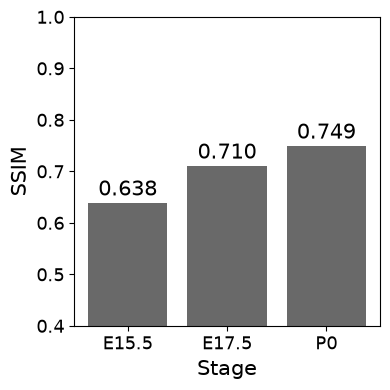

In [9]:
plt.figure(figsize=(4, 4))

plt.bar(
    ssim_df["stage_b"],
    ssim_df["S_color"],
    color="dimgray"
)

plt.xlabel("Stage",fontsize=15)
plt.ylabel("SSIM",fontsize=15)
plt.ylim(0.4, 1)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# 값 표시
for i, v in enumerate(ssim_df["S_color"]):
    plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=15)

plt.tight_layout()
plt.savefig("SSIM_purk_E17.5.png",bbox_inches="tight")
plt.show()

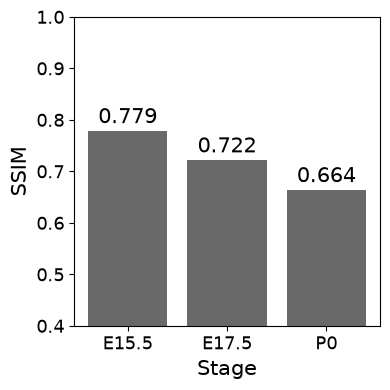

In [12]:
plt.figure(figsize=(4, 4))

plt.bar(
    ssim_df["stage_b"],
    ssim_df["S_color"],
    color="dimgray"
)

plt.xlabel("Stage",fontsize=15)
plt.ylabel("SSIM",fontsize=15)
plt.ylim(0.4, 1)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# 값 표시
for i, v in enumerate(ssim_df["S_color"]):
    plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=15)

plt.tight_layout()
plt.savefig("SSIM_gra_E17.5.png",bbox_inches="tight")
plt.show()

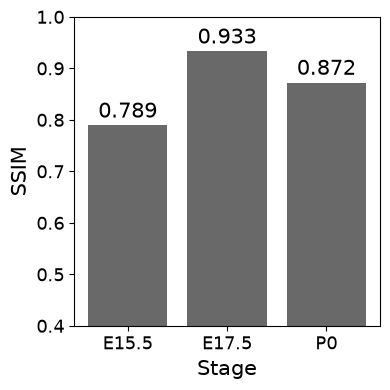

In [15]:
plt.figure(figsize=(4, 4))

plt.bar(
    ssim_df["stage_b"],
    ssim_df["S_color"],
    color="dimgray"
)

plt.xlabel("Stage",fontsize=15)
plt.ylabel("SSIM",fontsize=15)
plt.ylim(0.4, 1)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# 값 표시
for i, v in enumerate(ssim_df["S_color"]):
    plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=15)

plt.tight_layout()
plt.savefig("SSIM_inter_E17.5.png",bbox_inches="tight")
plt.show()

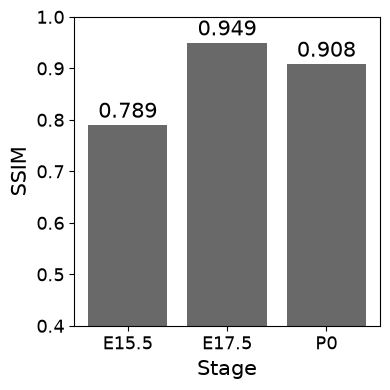

In [18]:
plt.figure(figsize=(4, 4))

plt.bar(
    ssim_df["stage_b"],
    ssim_df["S_color"],
    color="dimgray"
)

plt.xlabel("Stage",fontsize=15)
plt.ylabel("SSIM",fontsize=15)
plt.ylim(0.4, 1)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# 값 표시
for i, v in enumerate(ssim_df["S_color"]):
    plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=15)

plt.tight_layout()
plt.savefig("SSIM_glut_E17.5.png",bbox_inches="tight")
plt.show()

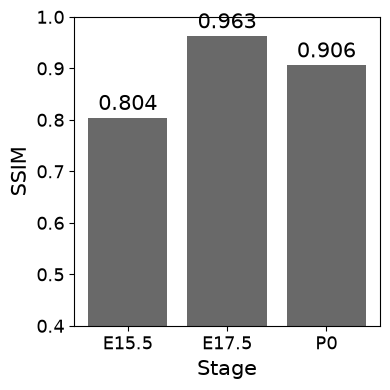

In [21]:
plt.figure(figsize=(4, 4))

plt.bar(
    ssim_df["stage_b"],
    ssim_df["S_color"],
    color="dimgray"
)

plt.xlabel("Stage",fontsize=15)
plt.ylabel("SSIM",fontsize=15)
plt.ylim(0.4, 1)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# 값 표시
for i, v in enumerate(ssim_df["S_color"]):
    plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=15)

plt.tight_layout()
plt.savefig("SSIM_gaba_E17.5.png",bbox_inches="tight")
plt.show()